IHD with 36 sujects, 

length of Aging_INDICES: 36


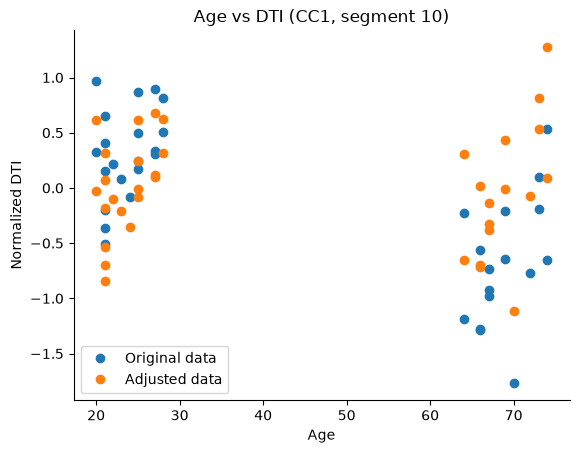

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import f_regression

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

pathfile=r'/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
pathfig=pathfile+'figures/'
os.chdir(pathfile)

addtotitle='_03022026_woMA_for_RD_MD_AD_FA' # to specify the version of the data

metricsDTI='FA' # to specify the DTI metric to use for the analysis



#_03022026_AllSubjects
Aging_INDICES_all = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler
scaler = RobustScaler()

DTI_all=np.zeros((36, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((36, 98, 7))  # 10 DTI metrics

for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_{metricsDTI}{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")

    DTI_all[:,:,i]=dfCCx[:36].values  ## une variable DTI of shape subjects x nodes x n CC
    
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx[:36].values)  ## une variable DTI of shape subjects x nodes x n CC

 # target var

import seaborn as sns
selection=[0,36] # to select only the 36 subjects with IHD
Aging_INDICES=Aging_INDICES_all[selection[0]:selection[1]] # only the 36 subjects with IHD

DTI=DTI_all[selection[0]:selection[1],:,:]  # only the 36 subjects with IHD

DTI_scaled=DTI_all_scaled[selection[0]:selection[1],:,:]  

age = Aging_INDICES['age'].values

### ATTENTION CIBLE IHD REMPLACANT JND
ihd = Aging_INDICES['IHD'].values
jnd = Aging_INDICES['JND_P'].values

# DTI values 

labels = [0,1]

Aging_INDICES['IHD_group'] = pd.qcut(Aging_INDICES['IHD'], q=2, labels=labels)
Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age_grouped = Aging_INDICES['group_O']
IHD_grouped = Aging_INDICES['IHD_group']
JND_grouped = Aging_INDICES['JND_group']

Aging_INDICES=Aging_INDICES[0:36] # only the 36 subjects with IHD

print('length of Aging_INDICES:', len(Aging_INDICES))

DTI_scaled_saved=DTI_scaled.copy() # to keep a copy of the original DTI values before adjustment


##############

import statsmodels.api as sm

DTI_adjusted = np.zeros_like(DTI_scaled)  # pour stocker les données DTI ajustées

for cc in range(7):
    for seg in range(98):
        data = DTI_scaled[:,seg,cc]  # on prend les données DTI du CC1 pour l'exemple
        data_adjusted = data.copy()
        X = sm.add_constant(age)
        y = data
        model = sm.OLS(y, X)
        results = model.fit()   
        residuals = results.resid
        data_adjusted = residuals

        DTI_adjusted[:,seg,cc] = data_adjusted  # stocker les données ajustées  


plt.plot(age, DTI_scaled_saved[:,10,0], 'o', label='Original data')
plt.plot(age, DTI_adjusted[:,10,0], 'o', label='Adjusted data')
plt.title('Age vs DTI (CC1, segment 10)')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.xlabel('Age')
plt.ylabel('Normalized DTI')
plt.legend()
plt.show()


ADJUST DATA DTI remove age effect on dti_scaled


F-value: 12.29629170543671, p-value: 0.0012971267549069536


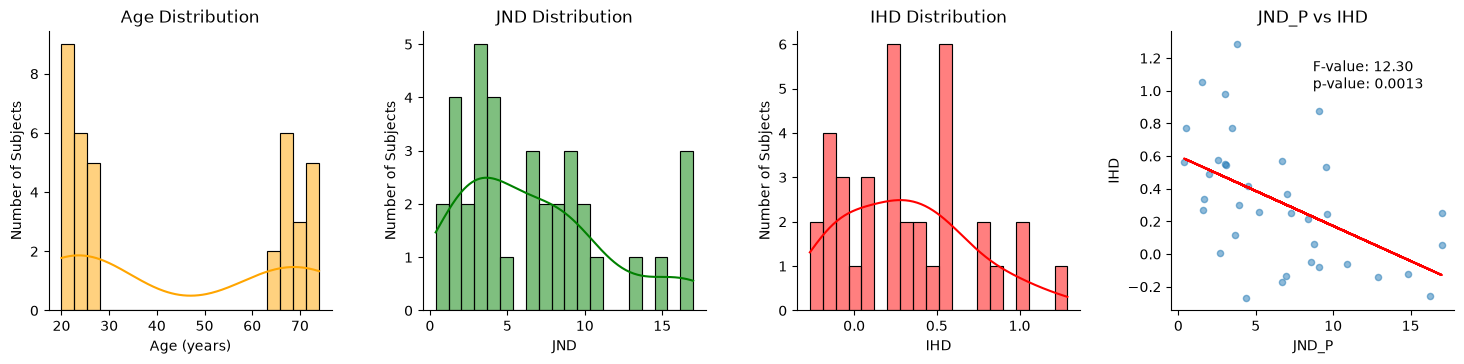

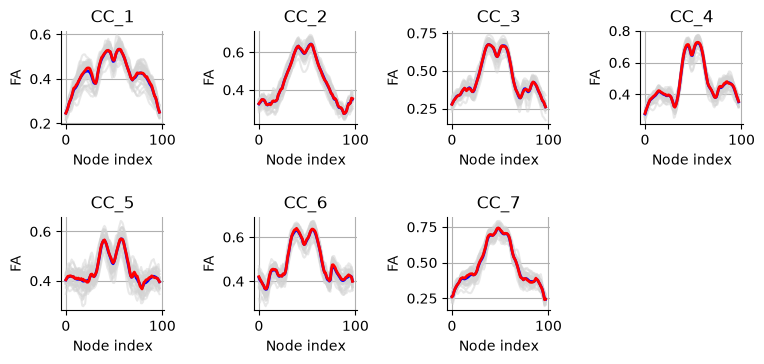

In [2]:
from sklearn.feature_selection import f_regression

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 4))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND Distribution')
axs[1].set_xlabel('JND')
axs[1].set_ylabel('Number of Subjects')
sns.histplot(ihd, bins=20, ax=axs[2],color='red',kde=True)
axs[2].set_title('IHD Distribution')
axs[2].set_xlabel('IHD')
axs[2].set_ylabel('Number of Subjects')


axs[3].scatter(jnd, ihd, alpha=0.5, s=20)
axs[3].set_title('JND_P vs IHD')
axs[3].set_xlabel('JND_P')
axs[3].set_ylabel('IHD')


coefficients = np.polyfit(jnd, ihd, 1)
polynomial = np.poly1d(coefficients)

f,p=f_regression(jnd.reshape(-1, 1), ihd)

print(f"F-value: {f[0]}, p-value: {p[0]}")
# Tracer les données et la régression linéaire
axs[3].plot(jnd, polynomial(jnd), color='red', label='Régression linéaire')
axs[3].text(0.5, 0.9, f'F-value: {f[0]:.2f}\np-value: {p[0]:.4f}', transform=axs[3].transAxes, fontsize=10, verticalalignment='top')
for i in range(4):
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.show()

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(8, 4))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI_all[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel(metricsDTI)
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)


fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)


Feat selectio based on simple lin regression using f_regression

Feat selection based on simple linear regression using f_regression

CC 1 - Best features for JND: [84 83 82 76 77 85 81 78 79 80]
CC 1 - Best features for Age: [15 16 14 13 17 12 18 19 11 82]
CC 1 - Best features for IHD: [78 80 82 79 81 77 76 83 75 74]
CC 2 - Best features for JND: [87 86 70 72 73 71 69 75 74 88]
CC 2 - Best features for Age: [70 72 71 82 83 81 73 88 69 62]
CC 2 - Best features for IHD: [29 30 28 24 68 31 26 67 63 69]
CC 3 - Best features for JND: [14 13 15 22 23 43 42 41 21 44]
CC 3 - Best features for Age: [42 41 43 40 66 39 67 23 65 14]
CC 3 - Best features for IHD: [65 66 64 15 14 42 16 67 43 13]
CC 4 - Best features for JND: [47 45 54 44 57 56 46 43 53 55]
CC 4 - Best features for Age: [77  5  6 76 78 69  7  4 70 55]
CC 4 - Best features for IHD: [68 67 69 66 70 65 77 76 64 63]
CC 5 - Best features for JND: [58 56 74 73 42 59 57 15 41 43]
CC 5 - Best features for Age: [73 74 72 75 11 10 12 13  8 56]
CC 5 - Best features for IHD: [56 57 55 58 54 43 53 42 13 44]
C

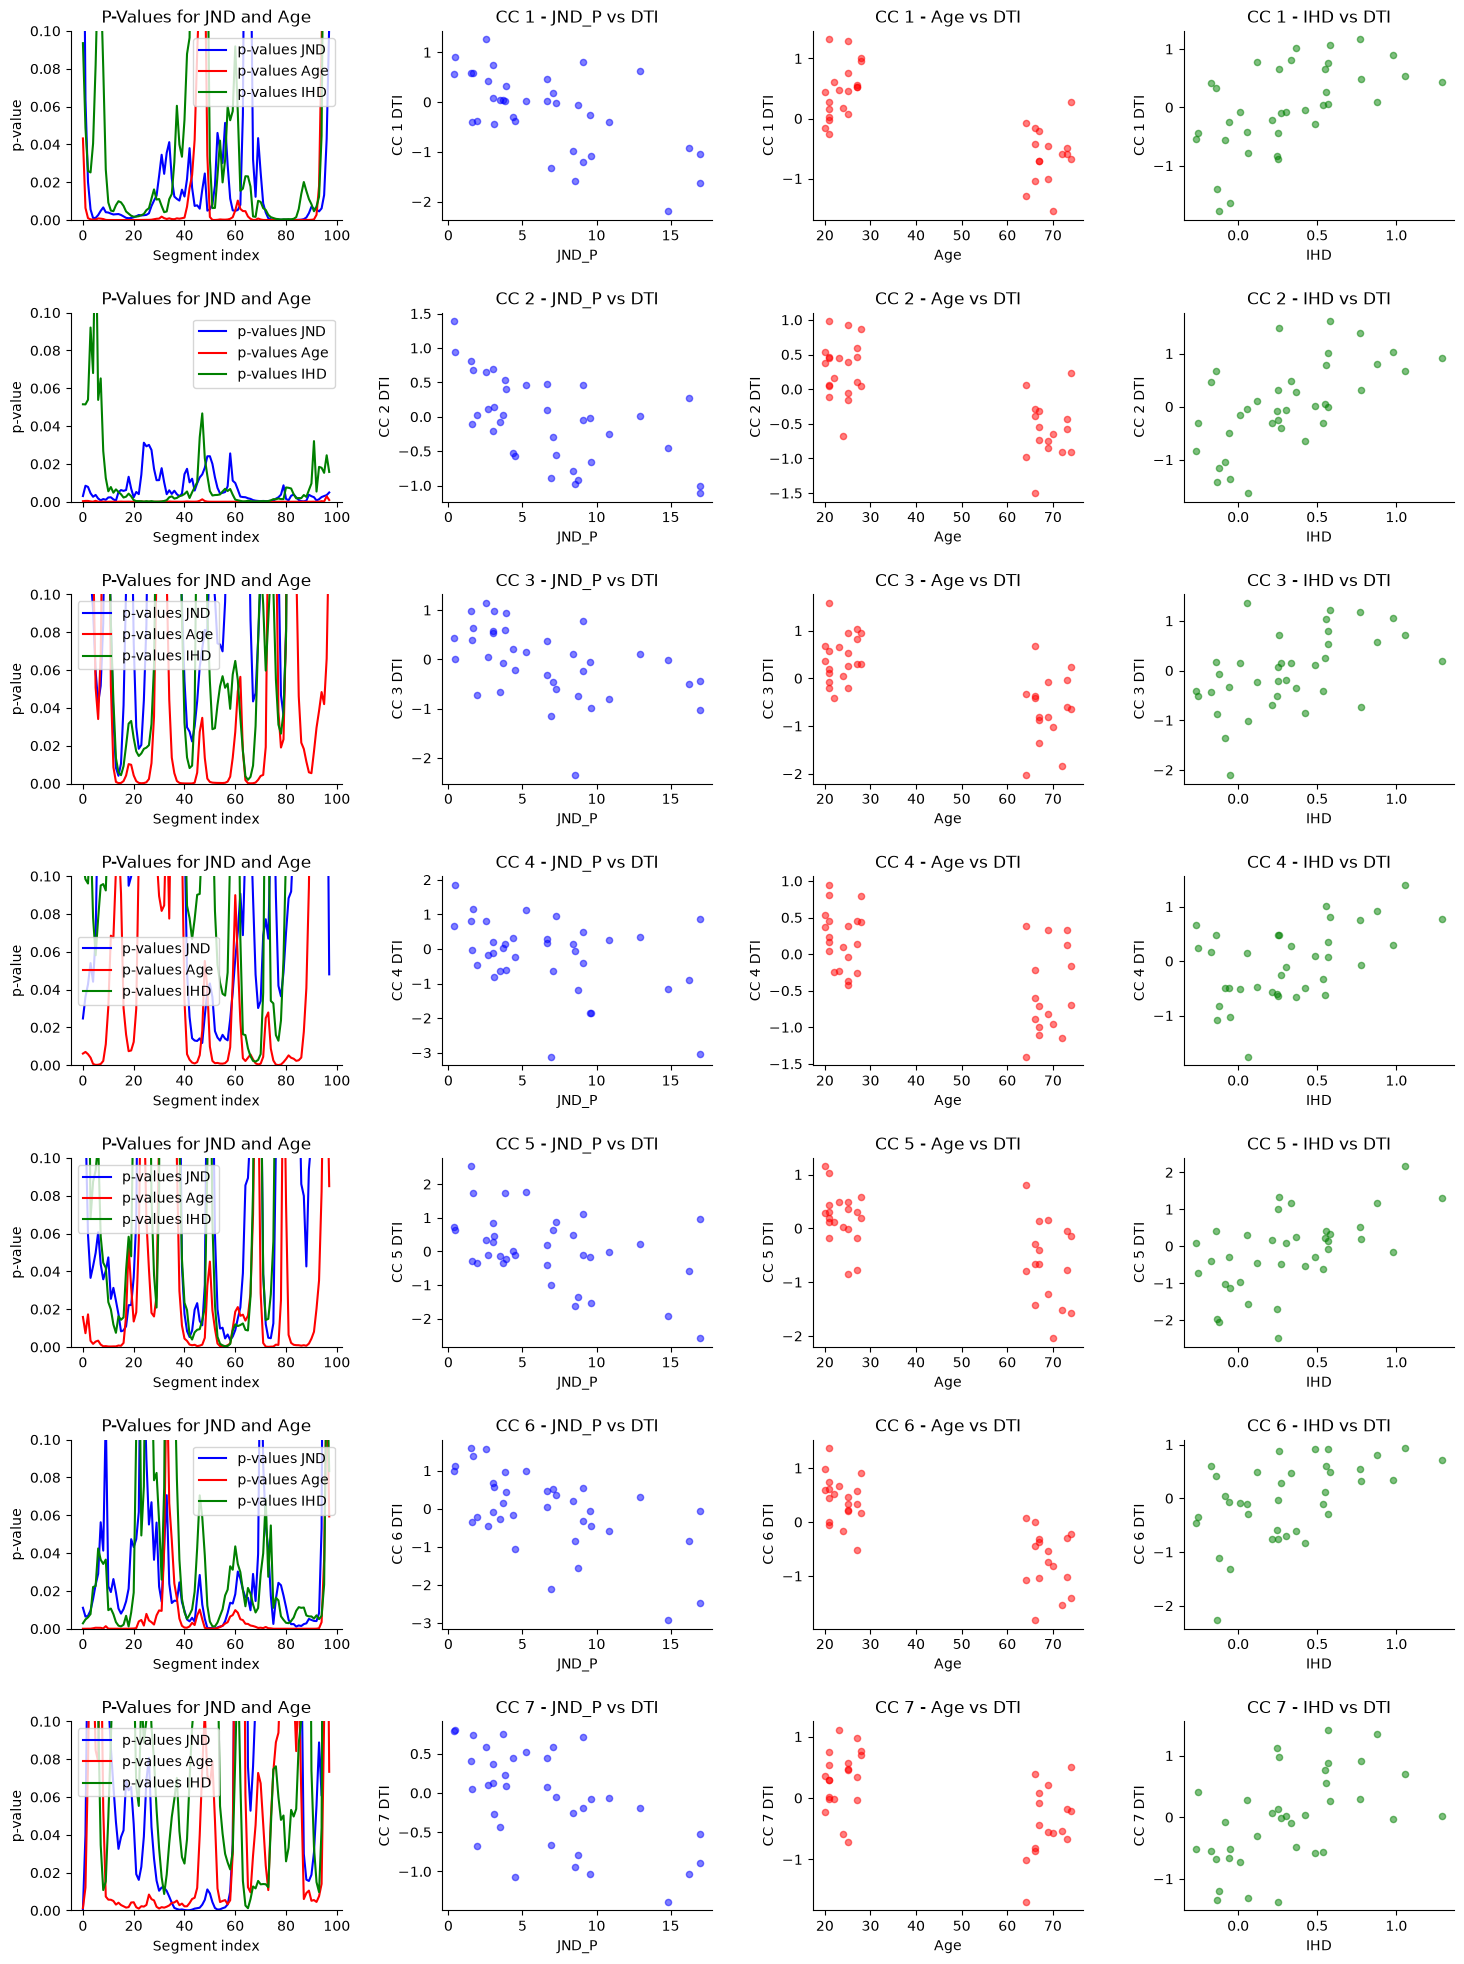

In [3]:
fig, axs = plt.subplots(nrows=7, ncols=4, figsize=(15, 20))

f_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
f_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)
f_reg_best_features_ihd_cc_allCC = np.zeros((7,10), dtype=int)

print('Feat selection based on simple linear regression using f_regression\n')

for cc in range(1,8):
        
    f_statistic_jnd, p_values_jnd = f_regression(DTI_scaled[:,:,cc-1], jnd )
    f_statistic_age, p_values_age = f_regression(DTI_scaled[:,:,cc-1], age )
    f_statistic_ihd, p_values_ihd = f_regression(DTI_scaled[:,:,cc-1], ihd )

    f_reg_best_features_jnd_cc = np.argsort(p_values_jnd)[:97]
    f_reg_best_features_age_cc = np.argsort(p_values_age)[:97]
    f_reg_best_features_ihd_cc = np.argsort(p_values_ihd)[:97]

    print(f'CC {cc} - Best features for JND: {f_reg_best_features_jnd_cc[:10]}')
    print(f'CC {cc} - Best features for Age: {f_reg_best_features_age_cc[:10]}')
    print(f'CC {cc} - Best features for IHD: {f_reg_best_features_ihd_cc[:10]}')

    f_reg_best_features_jnd_cc_allCC[cc-1,:]= f_reg_best_features_jnd_cc[:10]
    f_reg_best_features_age_cc_allCC[cc-1,:] = f_reg_best_features_age_cc[:10]
    f_reg_best_features_ihd_cc_allCC[cc-1,:] = f_reg_best_features_ihd_cc[:10]

    axs[cc-1,0].plot(p_values_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(p_values_age, color='red', label='p-values Age')
    axs[cc-1,0].plot(p_values_ihd, color='green', label='p-values IHD')

    axs[cc-1,0].set_ylim(0, 0.1)
    axs[cc-1,0].set_xlabel('Segment index')
    axs[cc-1,0].set_ylabel('p-value')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('P-Values for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)


    featn_jnd=f_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=f_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age
    featn_ihd=f_reg_best_features_ihd_cc[0]  # on prend la feature la plus significative pour IHD

    axs[cc-1,1].scatter(jnd, DTI_scaled[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_scaled[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,3].scatter(ihd, DTI_scaled[:,featn_ihd,cc-1], color='green', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,3].set_xlabel('IHD')
    axs[cc-1,3].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,3].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,3].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    axs[cc-1,3].set_title(f'CC {cc} - IHD vs DTI')

plt.tight_layout(pad=2.0)



based on r_regression

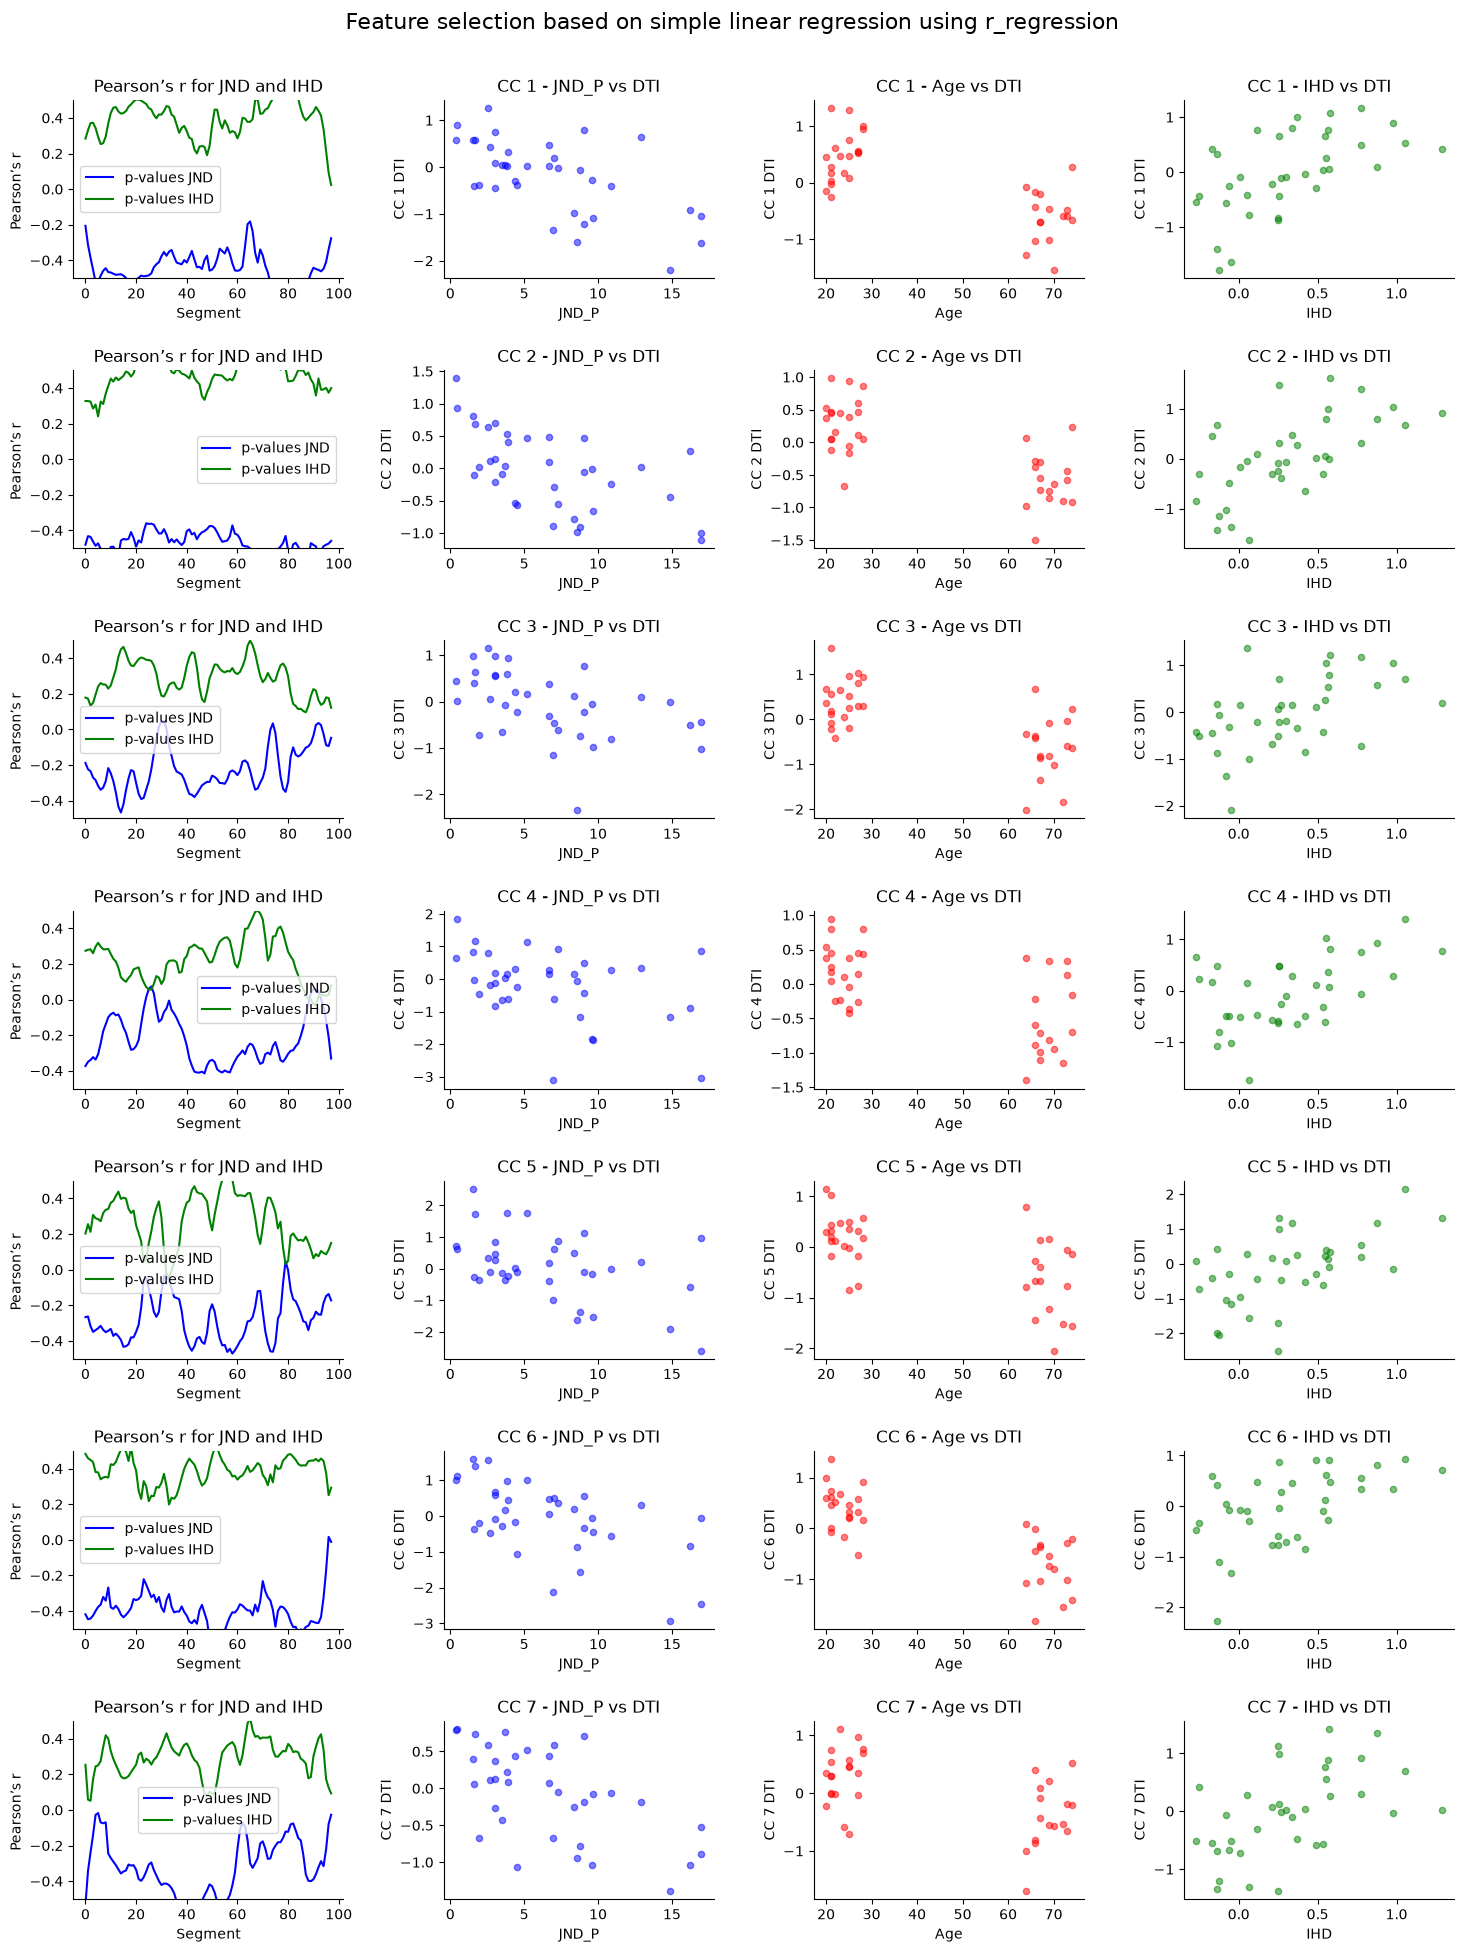

In [4]:
from sklearn.feature_selection import r_regression

####

from sklearn.feature_selection import r_regression

fig, axs = plt.subplots(nrows=7, ncols=4, figsize=(15, 20))

r_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_ihd_cc_allCC = np.zeros((7,10), dtype=int)

r_reg_age_allcc = np.zeros((7,98))
for cc in range(1,8):   

    r_reg_jnd = r_regression(DTI_scaled[:,:,cc-1], jnd)
    r_reg_age = r_regression(DTI_scaled[:,:,cc-1], age)
    r_reg_ihd = r_regression(DTI_scaled[:,:,cc-1], ihd)

    r_reg_age_allcc[cc-1,:] = r_reg_age
    
    r_reg_best_features_jnd_cc = np.argsort(r_reg_jnd)
    r_reg_best_features_age_cc = np.argsort(r_reg_age)
    r_reg_best_features_ihd_cc = np.argsort(r_reg_ihd)

     
    if metricsDTI=='FA':
        r_reg_best_features_jnd_cc_allCC[cc-1,:]= r_reg_best_features_jnd_cc[:10]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[:10]
        r_reg_best_features_ihd_cc_allCC[cc-1,:] = r_reg_best_features_ihd_cc[-10:]
    else: 
        r_reg_best_features_jnd_cc_allCC[cc-1,:] = r_reg_best_features_jnd_cc[-10:]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[-10:]
        r_reg_best_features_ihd_cc_allCC[cc-1,:] = r_reg_best_features_ihd_cc[:10]


    axs[cc-1,0].plot(r_reg_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(r_reg_ihd, color='green', label='p-values IHD')
    axs[cc-1,0].set_ylim(-0.5, 0.5)
    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Pearson’s r ')  
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Pearson’s r for JND and IHD')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

   
    featn_jnd=r_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=r_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age
    featn_ihd=r_reg_best_features_ihd_cc[-1:]  # on prend la feature la plus significative pour IHD

    axs[cc-1,1].scatter(jnd, DTI_scaled[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_scaled[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,3].scatter(ihd, DTI_scaled[:,featn_ihd,cc-1], color='green', label='Données', alpha=0.5, s=20)

    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,3].set_xlabel('IHD')
    axs[cc-1,3].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,3].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,3].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    axs[cc-1,3].set_title(f'CC {cc} - IHD vs DTI')

fig.suptitle('Feature selection based on simple linear regression using r_regression\n', fontsize=16)
    
plt.tight_layout(pad=2.0) 

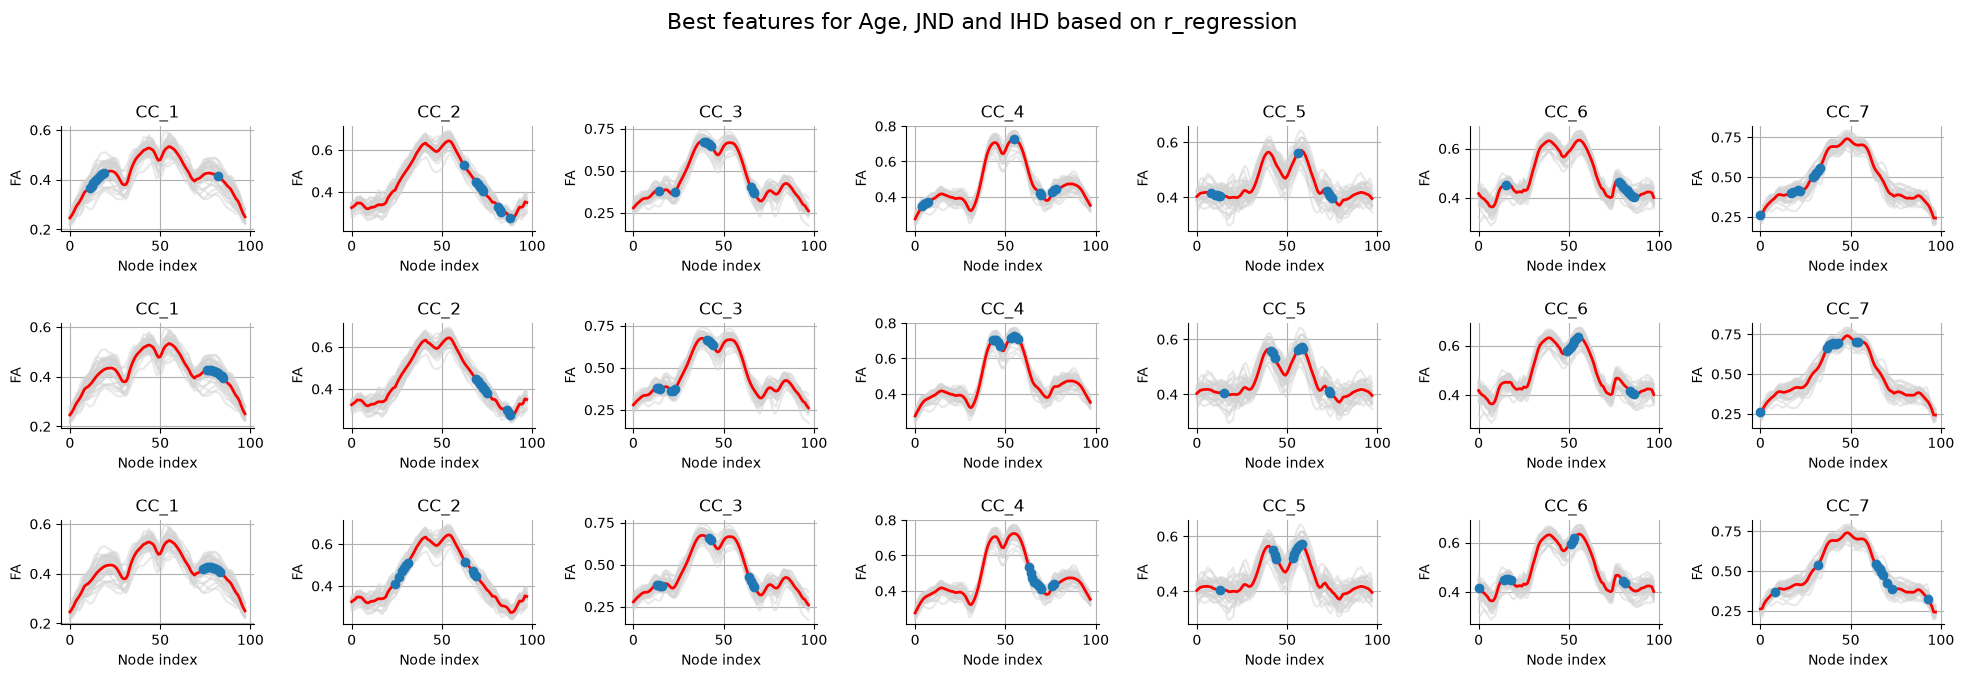

In [5]:

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=3, ncols=7, figsize=(20, 7))

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[0,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[0,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[0,i].plot(r_reg_best_features_age_cc_allCC[i,:], DTI[:,r_reg_best_features_age_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features Age')
    axs[0,i].set_xlabel('Node index')
    axs[0,i].set_ylabel('FA')
    axs[0,i].grid(True)
    axs[0,i].spines['top'].set_visible(False)
    axs[0,i].spines['right'].set_visible(False)
    axs[0,i].set_title(CCx)
   

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[1,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[1,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[1,i].plot(r_reg_best_features_jnd_cc_allCC[i,:], DTI[:,r_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features JND')
    axs[1,i].set_xlabel('Node index')
    axs[1,i].set_ylabel('FA')
    axs[1,i].grid(True)
    axs[1,i].spines['top'].set_visible(False)
    axs[1,i].spines['right'].set_visible(False)
    axs[1,i].set_title(CCx)

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[2,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[2,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[2,i].plot(r_reg_best_features_ihd_cc_allCC[i,:], DTI[:,r_reg_best_features_ihd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features IHD')
    axs[2,i].set_xlabel('Node index')
    axs[2,i].set_ylabel('FA')
    axs[2,i].grid(True)
    axs[2,i].spines['top'].set_visible(False)
    axs[2,i].spines['right'].set_visible(False)
    axs[2,i].set_title(CCx)

fig.suptitle('Best features for Age, JND and IHD based on r_regression\n', fontsize=16)
plt.tight_layout(pad=2.0)



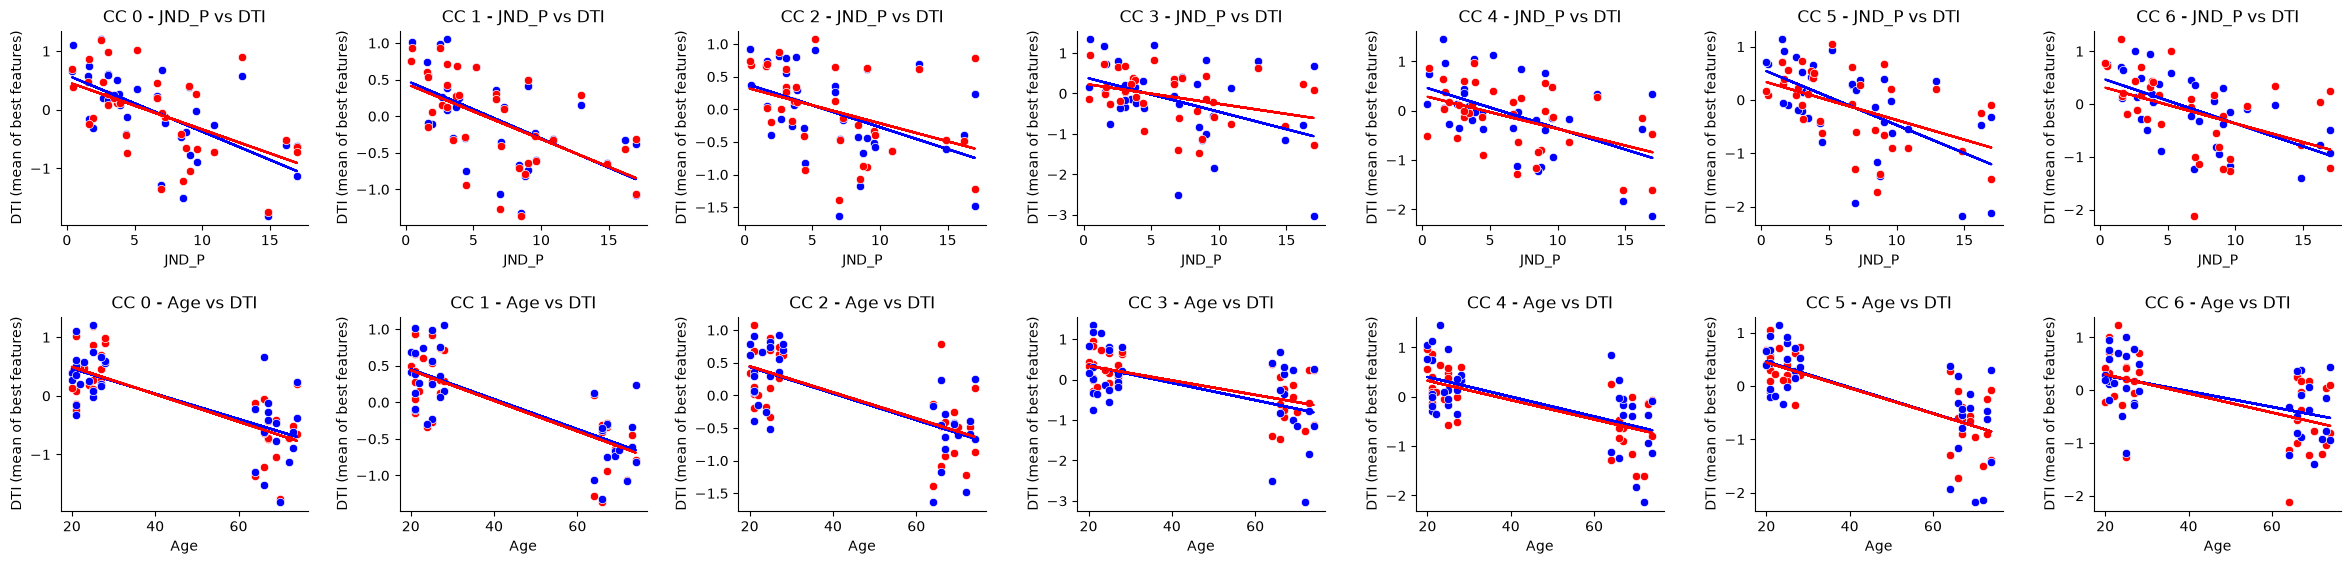

In [6]:
import statsmodels.api as sm
 

fig,axs = plt.subplots(nrows=2, ncols=7, figsize=(24,6))

for cc in range(7):

    x = sm.add_constant(jnd)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2


    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='blue')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='red') 
    axs[0,cc].set_title(f'CC {cc} - JND_P vs DTI')
    axs[0,cc].spines['top'].set_visible(False)
    axs[0,cc].spines['right'].set_visible(False)
    axs[0,cc].set_xlabel('JND_P')
    axs[0,cc].set_ylabel('DTI (mean of best features)')
    # Tracer la ligne de régression
    axs[0,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[0,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')



    
    x = sm.add_constant(age)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='red')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='blue')
    axs[1,cc].set_title(f'CC {cc} - Age vs DTI')
    axs[1,cc].spines['top'].set_visible(False)
    axs[1,cc].spines['right'].set_visible(False)
    axs[1,cc].set_xlabel('Age')
    axs[1,cc].set_ylabel('DTI (mean of best features)')
    axs[1,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[1,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')

plt.tight_layout(pad=2.0)



       


Regression prediction test on cc 7 best feat

In [7]:


DTI_JND=pd.DataFrame([])
DTI_AGE=pd.DataFrame([])
DTI_IHD=pd.DataFrame([])
for cc in range(1,8):
    DTI_JND_tmp=pd.DataFrame(DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc-1],cc-1])
    DTI_JND_tmp.columns = [f'CC{cc}_{idx}' for idx in r_reg_best_features_jnd_cc_allCC[cc-1]]
    DTI_JND=pd.concat([DTI_JND, DTI_JND_tmp], axis=1)

    DTI_AGE_tmp=pd.DataFrame(DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc-1],cc-1])
    DTI_AGE_tmp.columns = [f'CC{cc}_{idx}' for idx in r_reg_best_features_age_cc_allCC[cc-1]]
    DTI_AGE=pd.concat([DTI_AGE, DTI_AGE_tmp], axis=1)

    DTI_IHD_tmp=pd.DataFrame(DTI_scaled[:,r_reg_best_features_ihd_cc_allCC[cc-1],cc-1])
    DTI_IHD_tmp.columns = [f'CC{cc}_{idx}' for idx in r_reg_best_features_ihd_cc_allCC[cc-1]]
    DTI_IHD=pd.concat([DTI_IHD, DTI_IHD_tmp], axis=1)



DTI_IHD.describe()


,CC1_74,CC1_75,CC1_83,CC1_76,CC1_77,CC1_81,CC1_79,CC1_82,CC1_80,CC1_78,...,CC7_70,CC7_67,CC7_73,CC7_68,CC7_8,CC7_93,CC7_32,CC7_66,CC7_64,CC7_65
count,3.600000e+01,3.600000e+01,3.600000e+01,36.000000,3.600000e+01,36.000000,36.000000,3.600000e+01,36.000000,36.000000,...,3.600000e+01,3.600000e+01,36.000000,36.000000,3.600000e+01,3.600000e+01,36.000000,3.600000e+01,36.000000,36.000000
mean,-1.573412e-01,-2.126704e-02,-2.076731e-02,0.016495,2.206155e-02,-0.037826,-0.058409,2.111806e-02,-0.062073,-0.009815,...,1.190368e-01,8.379425e-03,0.011813,0.078666,-1.284859e-01,2.918302e-02,-0.163964,-4.624852e-02,0.069230,-0.024078
std,8.484222e-01,7.823643e-01,8.209440e-01,0.710482,7.194801e-01,0.700167,0.746824,6.857158e-01,0.787568,0.744978,...,7.943040e-01,1.089259e+00,0.936400,1.034187,7.610068e-01,7.561940e-01,0.750923,7.828248e-01,0.722854,0.747730
min,-2.302725e+00,-1.959753e+00,-1.917169e+00,-1.737734,-1.709153e+00,-1.585858,-1.823973,-1.498623e+00,-1.841375,-1.783957,...,-1.454724e+00,-3.014846e+00,-1.800053,-2.788643,-2.733770e+00,-1.335375e+00,-1.843753,-1.957321e+00,-1.405303,-1.374502
25%,-6.224295e-01,-4.274811e-01,-4.377573e-01,-0.339498,-3.678679e-01,-0.456633,-0.514104,-4.007465e-01,-0.488825,-0.437316,...,-3.817710e-01,-5.734680e-01,-0.540729,-0.490285,-5.493554e-01,-4.341737e-01,-0.741465,-6.115404e-01,-0.374676,-0.554336
50%,6.088879e-16,5.264886e-16,-6.878179e-16,0.000000,-4.753142e-16,0.000000,0.000000,5.490400e-16,0.000000,0.000000,...,4.996004e-16,-9.372928e-16,0.000000,0.000000,1.068590e-15,-8.257284e-16,0.000000,-1.545639e-15,0.000000,0.000000
75%,3.775705e-01,5.725189e-01,5.622427e-01,0.660502,6.321321e-01,0.543367,0.485896,5.992535e-01,0.511175,0.562684,...,6.182290e-01,4.265320e-01,0.459271,0.509715,4.506446e-01,5.658263e-01,0.258535,3.884596e-01,0.625324,0.445664
max,1.123330e+00,1.097502e+00,1.584382e+00,1.021037,1.037584e+00,1.284418,1.199412,1.327845e+00,1.385865,1.162843,...,2.078545e+00,3.377608e+00,1.992037,3.300110,9.879391e-01,2.025072e+00,1.514904,2.053977e+00,1.674931,1.416029


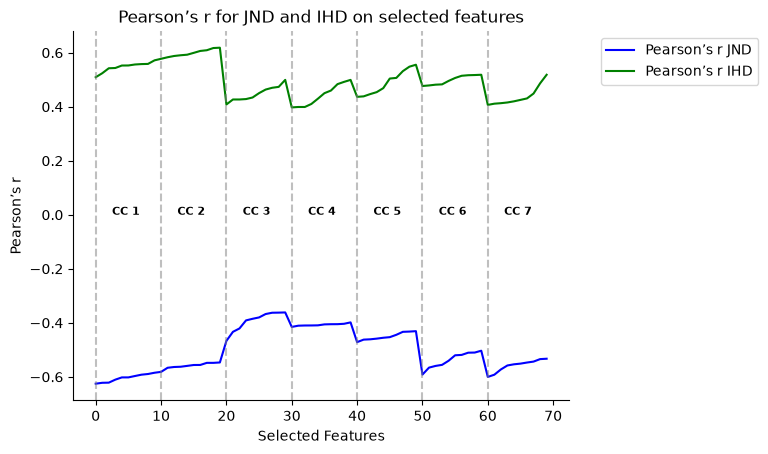

In [8]:
cc=1
r_reg_jnd70 = r_regression(DTI_JND, jnd)
r_reg_ihd70 = r_regression(DTI_IHD, ihd)


plt.plot(r_reg_jnd70, color='blue', label='Pearson’s r JND')
plt.plot(r_reg_ihd70, color='green', label='Pearson’s r IHD')
plt.xlabel('Selected Features')
plt.ylabel('Pearson’s r')
plt.title('Pearson’s r for JND and IHD on selected features')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')     

for i in range(7):
    plt.axvline(x=i*10, color='gray', linestyle='--', alpha=0.5)
    plt.text(i*10 + 2.5, max(max(r_reg_jnd70), 0), f'CC {i+1}', color='black', fontsize=8,weight='bold')


In [9]:
Aging_INDICES['JND_group3'] = pd.qcut(Aging_INDICES['JND_P'], q=3, labels=[0,1,2])
Aging_INDICES['IHD_group3'] = pd.qcut(Aging_INDICES['IHD'], q=3, labels=[0,1,2])
Aging_INDICES

,sub,age,group,JND_P,group_O,group_Y,IHD,IHD_group,JND_group,JND_group3,IHD_group3
0,sub-01,25,Y,9.56,0.0,1.0,0.534027,1,1,2,2
1,sub-02,27,Y,6.69,0.0,1.0,0.570600,1,1,1,2
2,sub-03,28,Y,12.92,0.0,1.0,-0.140120,0,1,2,0
3,sub-05,21,Y,1.95,0.0,1.0,0.488581,1,0,0,1
4,sub-06,25,Y,2.54,0.0,1.0,0.578001,1,0,0,2
5,sub-08,67,O,4.48,1.0,0.0,0.419239,1,0,1,1
6,sub-09,73,O,9.63,1.0,0.0,0.246470,0,1,2,1
7,sub-10,64,O,7.27,1.0,0.0,0.253942,0,1,1,1
8,sub-11,21,Y,1.62,0.0,1.0,0.268078,1,0,0,1
9,sub-12,21,Y,3.68,0.0,1.0,0.115833,0,0,1,1


JND_group
0    18
1    18
Name: count, dtype: int64
T-test JND group: t=3.9141, p=0.0004
T-test JND group: t=4.1139, p=0.0002
T-test Age group: t=5.4797, p=0.0000
T-test Age group: t=7.6567, p=0.0000


(36, 70)

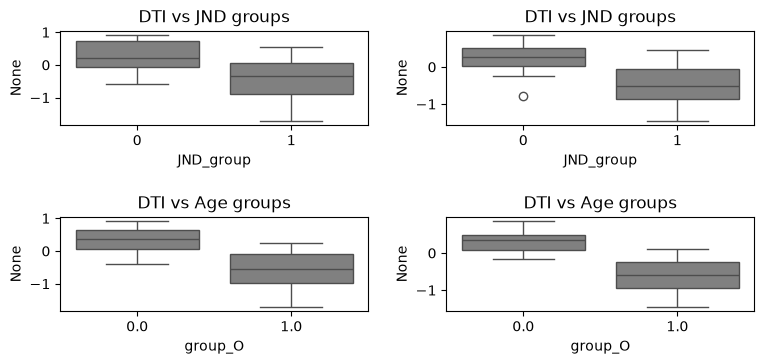

In [10]:
from scipy.stats import ttest_ind

fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(8,4))
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['JND_group'], color='grey', ax=axs[0,0])
axs[0,0].set_title('DTI vs JND groups')

sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['JND_group'], color='grey', ax=axs[0,1])
axs[0,1].set_title('DTI vs JND groups')
print(Aging_INDICES['JND_group'].value_counts())
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,0])
axs[1,0].set_title('DTI vs Age groups')
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,1])
axs[1,1].set_title('DTI vs Age groups')
plt.tight_layout(pad=2.0)

t,pval=ttest_ind(DTI_JND.mean(axis=1)[Aging_INDICES['JND_group']==0], DTI_JND.mean(axis=1)[Aging_INDICES['JND_group']==1])
print(f'T-test JND group: t={t:.4f}, p={pval:.4f}')
t,pval=ttest_ind(DTI_AGE.mean(axis=1)[Aging_INDICES['JND_group']==0], DTI_AGE.mean(axis=1)[Aging_INDICES['JND_group']==1])
print(f'T-test JND group: t={t:.4f}, p={pval:.4f}')
t,pval=ttest_ind(DTI_JND.mean(axis=1)[Aging_INDICES['group_O']==0], DTI_JND.mean(axis=1)[Aging_INDICES['group_O']==1])
print(f'T-test Age group: t={t:.4f}, p={pval:.4f}')
t,pval=ttest_ind(DTI_AGE.mean(axis=1)[Aging_INDICES['group_O']==0], DTI_AGE.mean(axis=1)[Aging_INDICES['group_O']==1])
print(f'T-test Age group: t={t:.4f}, p={pval:.4f}')
DTI_JND.shape

JND_group3
0    12
1    12
2    12
Name: count, dtype: int64


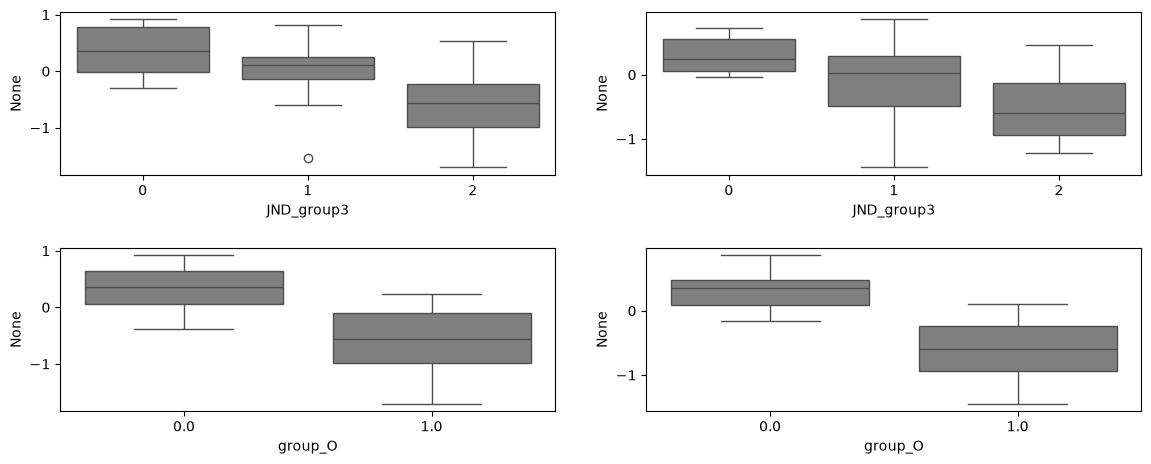

In [11]:


fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['JND_group3'], color='grey', ax=axs[0,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['JND_group3'], color='grey', ax=axs[0,1])
print(Aging_INDICES['JND_group3'].value_counts())
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,1])
plt.tight_layout(pad=2.0)



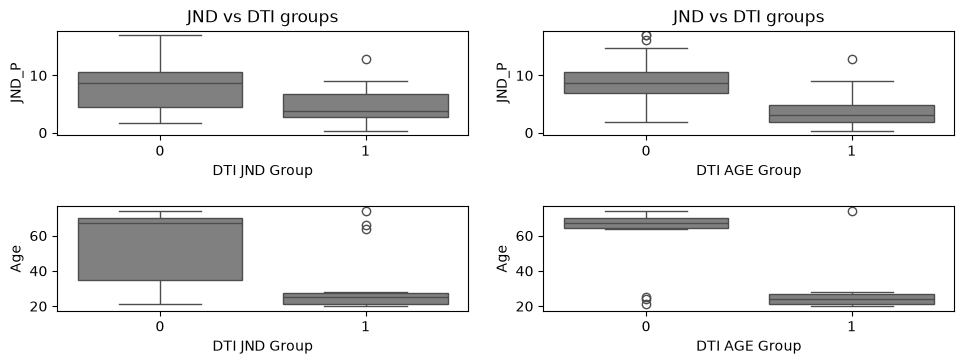

In [12]:
DTI_3g_JND = pd.qcut(DTI_JND.mean(axis=1), q=2, labels=[0,1])
DTI_3g_AGE = pd.qcut(DTI_AGE.mean(axis=1), q=2, labels=[0,1])

fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(10,4))

sns.boxplot(y=jnd,x=DTI_3g_JND,color='grey', ax=axs[0,0])
sns.boxplot(y=jnd,x=DTI_3g_AGE,color='grey', ax=axs[0,1])
axs[0,0].set_xlabel('DTI JND Group')
axs[0,0].set_ylabel('JND_P')
axs[0,1].set_xlabel('DTI AGE Group')
axs[0,1].set_ylabel('JND_P')

sns.boxplot(y=age,x=DTI_3g_JND,color='grey', ax=axs[1,0])
sns.boxplot(y=age,x=DTI_3g_AGE,color='grey', ax=axs[1,1])
axs[1,0].set_xlabel('DTI JND Group')
axs[1,0].set_ylabel('Age')
axs[1,1].set_xlabel('DTI AGE Group')
axs[1,1].set_ylabel('Age')

axs[0,0].set_title('JND vs DTI groups')
axs[0,1].set_title('JND vs DTI groups')
plt.tight_layout(pad=2.0)



Text(0.5, 1.0, 'JND vs DTI groups')

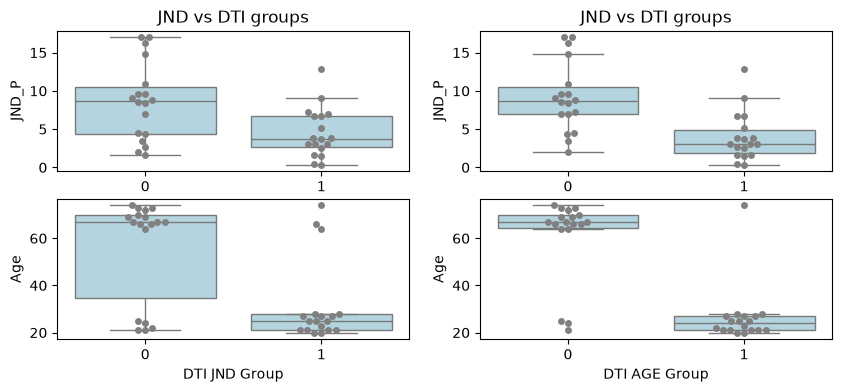

In [13]:
fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(10,4))

sns.swarmplot(y=jnd,x=DTI_3g_JND,color='grey', ax=axs[0,0])
sns.boxplot(y=jnd,x=DTI_3g_JND,color='lightblue', ax=axs[0,0], showfliers=False)

sns.swarmplot(y=jnd,x=DTI_3g_AGE,color='grey', ax=axs[0,1])
sns.boxplot(y=jnd,x=DTI_3g_AGE,color='lightblue', ax=axs[0,1], showfliers=False)
axs[0,0].set_xlabel('DTI JND Group')
axs[0,0].set_ylabel('JND_P')
axs[0,1].set_xlabel('DTI AGE Group')
axs[0,1].set_ylabel('JND_P')
sns.swarmplot(y=age,x=DTI_3g_JND,color='grey', ax=axs[1,0])
sns.boxplot(y=age,x=DTI_3g_JND,color='lightblue', ax=axs[1,0], showfliers=False)
sns.swarmplot(y=age,x=DTI_3g_AGE,color='grey', ax=axs[1,1])
sns.boxplot(y=age,x=DTI_3g_AGE,color='lightblue', ax=axs[1,1], showfliers=False)
axs[1,0].set_xlabel('DTI JND Group')
axs[1,0].set_ylabel('Age')
axs[1,1].set_xlabel('DTI AGE Group')
axs[1,1].set_ylabel('Age')
axs[0,0].set_title('JND vs DTI groups')
axs[0,1].set_title('JND vs DTI groups')


In [14]:
Aging_INDICES

,sub,age,group,JND_P,group_O,group_Y,IHD,IHD_group,JND_group,JND_group3,IHD_group3
0,sub-01,25,Y,9.56,0.0,1.0,0.534027,1,1,2,2
1,sub-02,27,Y,6.69,0.0,1.0,0.570600,1,1,1,2
2,sub-03,28,Y,12.92,0.0,1.0,-0.140120,0,1,2,0
3,sub-05,21,Y,1.95,0.0,1.0,0.488581,1,0,0,1
4,sub-06,25,Y,2.54,0.0,1.0,0.578001,1,0,0,2
5,sub-08,67,O,4.48,1.0,0.0,0.419239,1,0,1,1
6,sub-09,73,O,9.63,1.0,0.0,0.246470,0,1,2,1
7,sub-10,64,O,7.27,1.0,0.0,0.253942,0,1,1,1
8,sub-11,21,Y,1.62,0.0,1.0,0.268078,1,0,0,1
9,sub-12,21,Y,3.68,0.0,1.0,0.115833,0,0,1,1


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score


jnd_grouped = pd.qcut(jnd, q=2, labels=[0, 1])
age_grouped = pd.qcut(age, q=2, labels=[0, 1])
ihd_grouped = pd.qcut(ihd, q=2, labels=[0, 1])


colors = sns.color_palette('Set2')
first_color = colors[0]
second_color = colors[1]



In [16]:
df

NameError: name 'df' is not defined

In [ ]:
from scipy import stats
stat, p_value = stats.shapiro(roc_auc_all[1])
print(f'Shapiro-Wilk test statistic: {stat:.4f}, p-value: {p_value:.4f}')
if p_value > 0.05:
        print("Les données semblent normales (ne rejeter pas H0)")
else:
        print("Les données ne semblent pas normales (rejeter H0)")
    
stat, p_value = stats.mannwhitneyu(roc_auc_all[0], roc_auc_all[1], alternative='two-sided')
print(f'Mann-Whitney U test statistic: {stat:.4f}, p-value: {p_value:.4f}')

stat, p_value = stats.mannwhitneyu(roc_auc_all[1], np.full_like(roc_auc_all[1], 0.5), alternative='greater')
print(f'Wilcoxon signed-rank test statistic: {stat:.4f}, p-value: {p_value:.4f}')

NameError: name 'roc_auc_all' is not defined

CC 1: P-value for the overall model: 0.1381
CC 2: P-value for the overall model: 0.3567
CC 3: P-value for the overall model: 0.8941
CC 4: P-value for the overall model: 0.5576
CC 5: P-value for the overall model: 0.3613
CC 6: P-value for the overall model: 0.2272
CC 7: P-value for the overall model: 0.0476


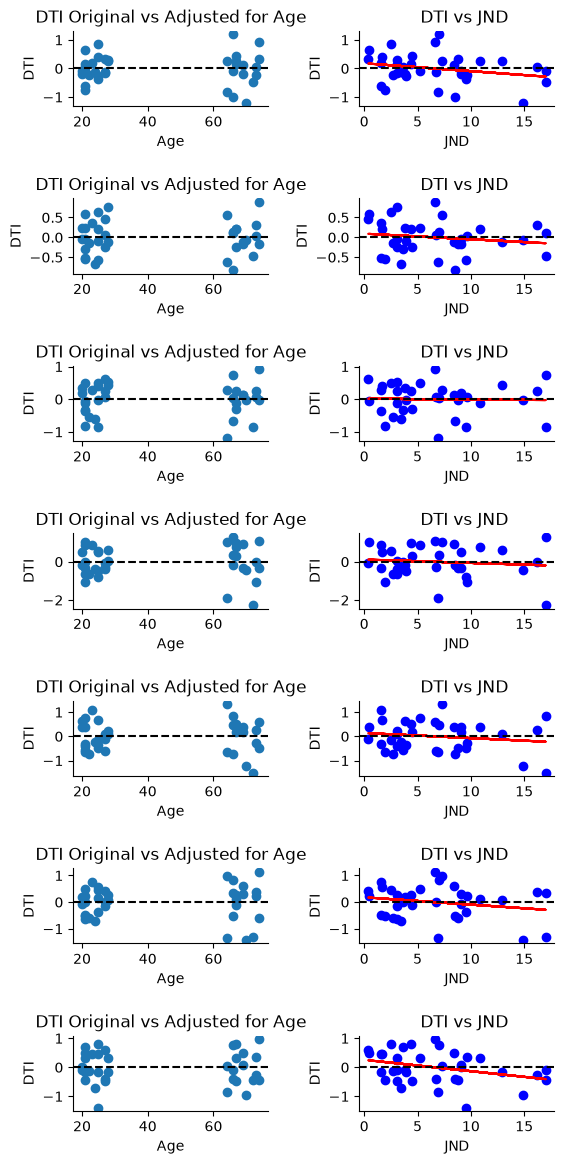

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=7, ncols=2, figsize=(6,12))


for cc in range(1,8):
        
    data = DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+10].tolist()].mean(axis=1)

    data_adjusted = data.copy()

    ### enlever l'effet de l'âge sur le DTI

    # Ajouter une constante à la variable indépendante
    X = sm.add_constant(age)
    y = data

    # Créer le modèle de régression multiple
    model = sm.OLS(y, X)

    # Ajuster le modèle
    results = model.fit()   

    # Calculer les résidus
    residuals = results.resid

    # Mettre à jour les données DTI avec les résidus
    data_adjusted = residuals

    ## test l effet du JND sur le DTI ajusté pour l'âge

    X = sm.add_constant(jnd)
    y = data_adjusted.values

    model = sm.OLS(y, X)
    results = model.fit()
    slope = results.params[1]
    intercept = results.params[0]
    regression_line = slope * jnd + intercept



    axs[cc-1,0].scatter(age, data_adjusted, label='DTI Adjusted')
    axs[cc-1,0].set_xlabel('Age')
    axs[cc-1,0].set_ylabel('DTI')
    axs[cc-1,0].axhline(0, color='black', linestyle='--', label='Zero Line')
    axs[cc-1,0].set_title('DTI Original vs Adjusted for Age')

    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

    axs[cc-1,1].scatter(jnd, data_adjusted, color='blue', label='Données')
    axs[cc-1,1].plot(jnd, regression_line, color='red')
    axs[cc-1,1].set_xlabel('JND')
    axs[cc-1,1].set_ylabel('DTI')
    axs[cc-1,1].set_title('   DTI vs JND')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,1].axhline(0, color='black', linestyle='--', label='Zero Line')

    # Afficher le graphique
    # print(results.summary())
    f_pvalue = results.f_pvalue
    print(f'CC {cc}: P-value for the overall model: {f_pvalue:.4f}')

plt.tight_layout(pad=2.0)



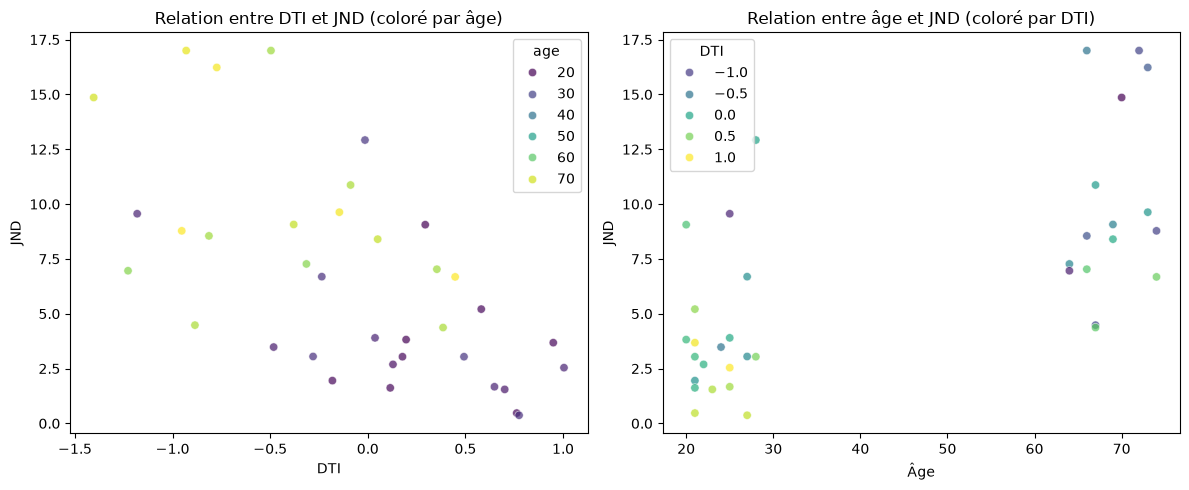

ModuleNotFoundError: No module named 'emoji'

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

pvaDTIlue = []

nseg=10

for cc in range(1,8):
            
    data = DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+nseg].tolist()].mean(axis=1)

    np.random.seed(42)
    n = 100
    df = pd.DataFrame({
        'DTI': data,  # Variable indépendante
        'age': age,  # Variable de contrôle
        'jnd': jnd,   # Variable dépendante
        'ihd': ihd   # Variable dépendante
    })

    # 2. Préparer les variables pour la régression
    X = df[['DTI', 'age']]  # Variables explicatives
    X = sm.add_constant(X)  # Ajoute une constante pour l'interception
    y = df['jnd']  # Variable à expliquer

    # 3. Ajuster le modèle de régression multiple
    model = sm.OLS(y, X).fit()

    pvaDTIlue.append(model.pvalues['DTI'])

# print(model.summary())

# # 4. Afficher les résultats de manière claire
# print("\n--- Résultats de la régression ---")
# print(f"Coefficient du DTI : {model.params['DTI']:.4f}")
# print(f"P-valeur du DTI : {model.pvalues['DTI']:.4f}")
# print(f"Coefficient de l'âge : {model.params['age']:.4f}")
# print(f"P-valeur de l'âge : {model.pvalues['age']:.4f}")
# print(f"R-carré : {model.rsquared:.3f}")
# print(f"F-statistique : {model.fvalue:.2f} (p-valeur : {model.f_pvalue:.4f})")

# 5. Visualisation
plt.figure(figsize=(12, 5))

# Scatter plot : DTI vs JND, coloré par âge
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='DTI', y='jnd', hue='age', palette='viridis', alpha=0.7)
plt.title("Relation entre DTI et JND (coloré par âge)")
plt.xlabel("DTI")
plt.ylabel("JND")

# Scatter plot : Age vs JND
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='age', y='jnd', hue='DTI', palette='viridis', alpha=0.7)
plt.title("Relation entre âge et JND (coloré par DTI)")
plt.xlabel("Âge")
plt.ylabel("JND")

plt.tight_layout()
plt.show()

import emoji

print('_____________________' + metricsDTI+ '_____________________')
for cc in range(7):
    print('________________________________________')
    print(metricsDTI + '  \ segment cc: ', cc+1, r_reg_best_features_jnd_cc_allCC[cc,:].tolist())
    print('p-value  pour cc {}: {:.3}'.format(cc+1, pvaDTIlue[cc] ))
    if pvaDTIlue[cc] * 7 < 0.05:
        emojipv=emoji.emojize(':check_mark_button:')
    else:        emojipv=emoji.emojize(':cross_mark:')
    print('p-value bonf. corrected pour cc {}: {:.3f}'.format(cc+1, pvaDTIlue[cc] * 7), emojipv)

In [ ]:
for cc in range(7):
    print('segment cc: ', cc+1, r_reg_best_features_jnd_cc_allCC[cc,:].tolist())

segment cc:  1 [84, 83, 82, 76, 77, 85, 81, 78, 79, 80]
segment cc:  2 [87, 86, 70, 72, 73, 71, 69, 75, 74, 88]
segment cc:  3 [14, 13, 15, 22, 23, 43, 42, 41, 21, 44]
segment cc:  4 [47, 45, 54, 44, 57, 56, 46, 43, 53, 55]
segment cc:  5 [58, 56, 74, 73, 42, 59, 57, 15, 41, 43]
segment cc:  6 [52, 51, 50, 49, 53, 84, 54, 86, 55, 85]
segment cc:  7 [41, 42, 40, 38, 43, 53, 39, 54, 37, 0]


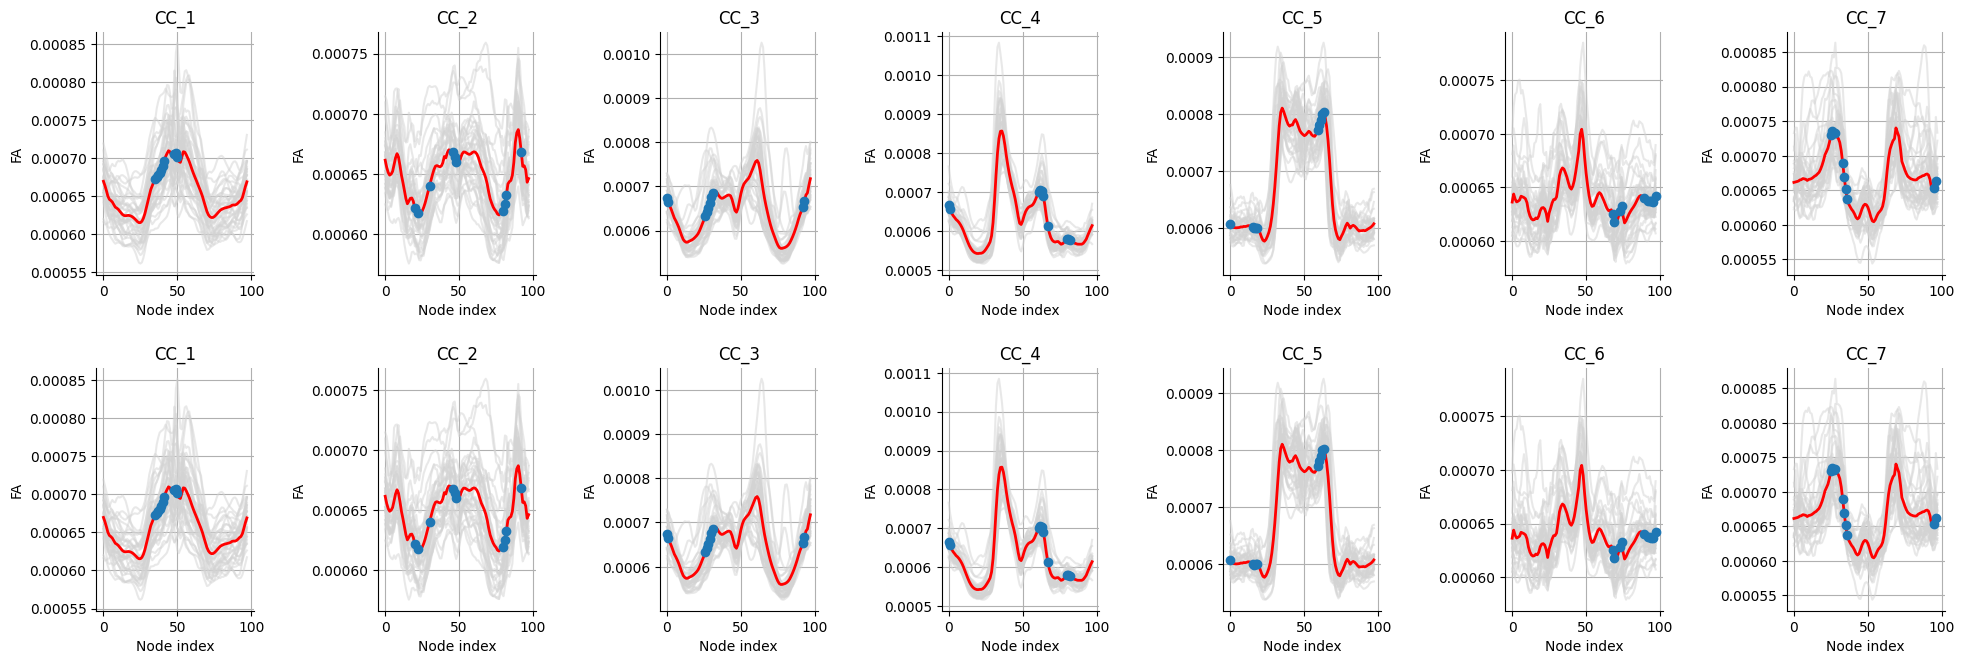

In [ ]:

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=7, figsize=(20, 7))

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[0,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[0,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[0,i].plot(f_reg_best_features_jnd_cc_allCC[i,:], DTI[:,f_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features Age')
    axs[0,i].set_xlabel('Node index')
    axs[0,i].set_ylabel('FA')
    axs[0,i].grid(True)
    axs[0,i].spines['top'].set_visible(False)
    axs[0,i].spines['right'].set_visible(False)
    axs[0,i].set_title(CCx)
   

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[1,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[1,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[1,i].plot(r_reg_best_features_jnd_cc_allCC[i,:], DTI[:,r_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features JND')
    axs[1,i].set_xlabel('Node index')
    axs[1,i].set_ylabel('FA')
    axs[1,i].grid(True)
    axs[1,i].spines['top'].set_visible(False)
    axs[1,i].spines['right'].set_visible(False)
    axs[1,i].set_title(CCx)

plt.tight_layout(pad=2.0)


IHD

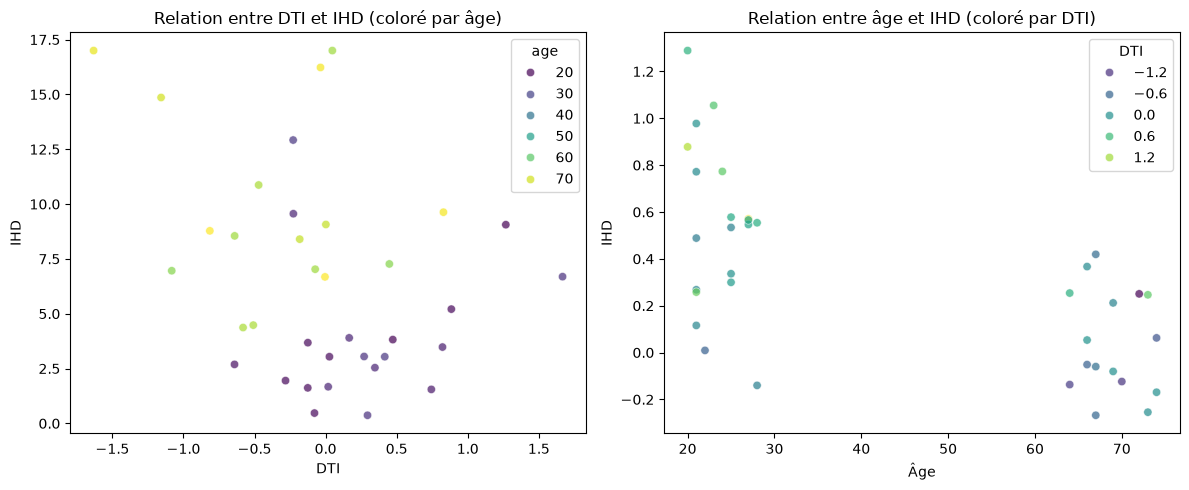

_____________________FA_____________________
________________________________________
FA  \ segment cc:  1 [84, 83, 82, 76, 77, 85, 81, 78, 79, 80]
p-value  pour cc 1: 0.228
p-value bonf. corrected pour cc 1: 1.599 ❌
________________________________________
FA  \ segment cc:  2 [87, 86, 70, 72, 73, 71, 69, 75, 74, 88]
p-value  pour cc 2: 0.0603
p-value bonf. corrected pour cc 2: 0.422 ❌
________________________________________
FA  \ segment cc:  3 [14, 13, 15, 22, 23, 43, 42, 41, 21, 44]
p-value  pour cc 3: 0.382
p-value bonf. corrected pour cc 3: 2.677 ❌
________________________________________
FA  \ segment cc:  4 [47, 45, 54, 44, 57, 56, 46, 43, 53, 55]
p-value  pour cc 4: 0.274
p-value bonf. corrected pour cc 4: 1.919 ❌
________________________________________
FA  \ segment cc:  5 [58, 56, 74, 73, 42, 59, 57, 15, 41, 43]
p-value  pour cc 5: 0.129
p-value bonf. corrected pour cc 5: 0.903 ❌
________________________________________
FA  \ segment cc:  6 [52, 51, 50, 49, 53, 84, 54, 86,

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

pvaDTIlue = []

nseg=10

for cc in range(1,8):
            
    data = DTI_IHD[DTI_IHD.columns[10*(cc-1):10*(cc-1)+nseg].tolist()].mean(axis=1)

    np.random.seed(42)
    n = 100
    df = pd.DataFrame({
        'DTI': data,  # Variable indépendante
        'age': age,  # Variable de contrôle
        'jnd': jnd,   # Variable dépendante
        'ihd': ihd   # Variable dépendante
    })

    # 2. Préparer les variables pour la régression
    X = df[['DTI', 'age']]  # Variables explicatives
    X = sm.add_constant(X)  # Ajoute une constante pour l'interception
    y = df['ihd']  # Variable à expliquer

    # 3. Ajuster le modèle de régression multiple
    model = sm.OLS(y, X).fit()

    pvaDTIlue.append(model.pvalues['DTI'])

# print(model.summary())

# # 4. Afficher les résultats de manière claire
# print("\n--- Résultats de la régression ---")
# print(f"Coefficient du DTI : {model.params['DTI']:.4f}")
# print(f"P-valeur du DTI : {model.pvalues['DTI']:.4f}")
# print(f"Coefficient de l'âge : {model.params['age']:.4f}")
# print(f"P-valeur de l'âge : {model.pvalues['age']:.4f}")
# print(f"R-carré : {model.rsquared:.3f}")
# print(f"F-statistique : {model.fvalue:.2f} (p-valeur : {model.f_pvalue:.4f})")

# 5. Visualisation
plt.figure(figsize=(12, 5))

# Scatter plot : DTI vs JND, coloré par âge
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='DTI', y='jnd', hue='age', palette='viridis', alpha=0.7)
plt.title("Relation entre DTI et IHD (coloré par âge)")
plt.xlabel("DTI")
plt.ylabel("IHD")

# Scatter plot : Age vs IHD
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='age', y='ihd', hue='DTI', palette='viridis', alpha=0.7)
plt.title("Relation entre âge et IHD (coloré par DTI)")
plt.xlabel("Âge")
plt.ylabel("IHD")

plt.tight_layout()
plt.show()

import emoji

print('_____________________' + metricsDTI+ '_____________________')
for cc in range(7):
    print('________________________________________')
    print(metricsDTI + '  \ segment cc: ', cc+1, r_reg_best_features_jnd_cc_allCC[cc,:].tolist())
    print('p-value  pour cc {}: {:.3}'.format(cc+1, pvaDTIlue[cc] ))
    if pvaDTIlue[cc] * 7 < 0.05:
        emojipv=emoji.emojize(':check_mark_button:')
    else:        emojipv=emoji.emojize(':cross_mark:')
    print('p-value bonf. corrected pour cc {}: {:.3f}'.format(cc+1, pvaDTIlue[cc] * 7), emojipv)

In [ ]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt


def test_covariate_adjusted_association(df, outcome_col, covariate_col, predictor_col,  plot=True,axs)
    """Teste l'association outcome ~ predictor en controlant pour covariate.

    - joint_model : regression multiple outcome ~ predictor + covariate (fait foi pour la p-valeur)
    - les graphiques utilisent une double residualisation (Frisch-Waugh-Lovell) :
      outcome et predictor sont chacun debarrasses de l'effet de covariate avant d'etre compares,
      ce qui rend le partial regression plot coherent avec joint_model.
    """
    data = df[[outcome_col, covariate_col, predictor_col]].dropna()

    # 1) Regression jointe : seule source valide pour le coefficient/p-value de predictor_col
    X_full = sm.add_constant(data[[predictor_col, covariate_col]])
    joint_model = sm.OLS(data[outcome_col], X_full).fit()

    # 2) Double residualisation, uniquement pour la visualisation
    X_cov = sm.add_constant(data[covariate_col])
    outcome_resid = sm.OLS(data[outcome_col], X_cov).fit().resid
    predictor_resid = sm.OLS(data[predictor_col], X_cov).fit().resid

    fig,axs = plt.subplots(1,2,figsize=(12,5))
    if plot:

        axs[i,0].scatter(data[covariate_col], data[outcome_col], alpha=0.6, label='Donnees brutes')
        axs[i,0].scatter(data[covariate_col], outcome_resid, alpha=0.6, color='red', label='Residus (effet covariate retire)')
        axs[i,0].axhline(0, color='black', linestyle='--', linewidth=0.8)
        axs[i,0].set_xlabel(covariate_col)
        axs[i,0].set_ylabel(outcome_col)
        axs[i,0].set_title(f'{outcome_col} brut vs ajuste pour {covariate_col}')

        axs[i,0].legend()

        slope, intercept = np.polyfit(predictor_resid, outcome_resid, 1)
        line_x = np.linspace(predictor_resid.min(), predictor_resid.max(), 100)
        axs[i,1].scatter(predictor_resid, outcome_resid, alpha=0.6)
        axs[i,1].plot(line_x, slope * line_x + intercept, color='red')
        axs[i,1].axhline(0, color='black', linestyle='--', linewidth=0.8)
        axs[i,1].set_xlabel(f'{predictor_col} (ajuste pour {covariate_col})')
        axs[i,1].set_ylabel(f'{outcome_col} (ajuste pour {covariate_col})')
        axs[i,1].set_title('Partial regression plot (Frisch-Waugh-Lovell)')
     
    # plt.savefig(pathfig + f'Partial_regression_plot_{outcome_col}_vs_JND_P_adjusted_for_age.png', dpi=300)
    
    print(f"--- Regression jointe : {outcome_col} ~ {predictor_col} + {covariate_col} ---")
    print(f"Coefficient {predictor_col} (effet partiel ajuste pour {covariate_col}) : {joint_model.params[predictor_col]:.4f}")
    print(f"P-valeur {predictor_col} : {joint_model.pvalues[predictor_col]:.4f}")
    print(f"Coefficient {covariate_col} : {joint_model.params[covariate_col]:.4f}")
    print(f"P-valeur {covariate_col} : {joint_model.pvalues[covariate_col]:.4f}")
    print(f"R-carre : {joint_model.rsquared:.3f}")

    return joint_model



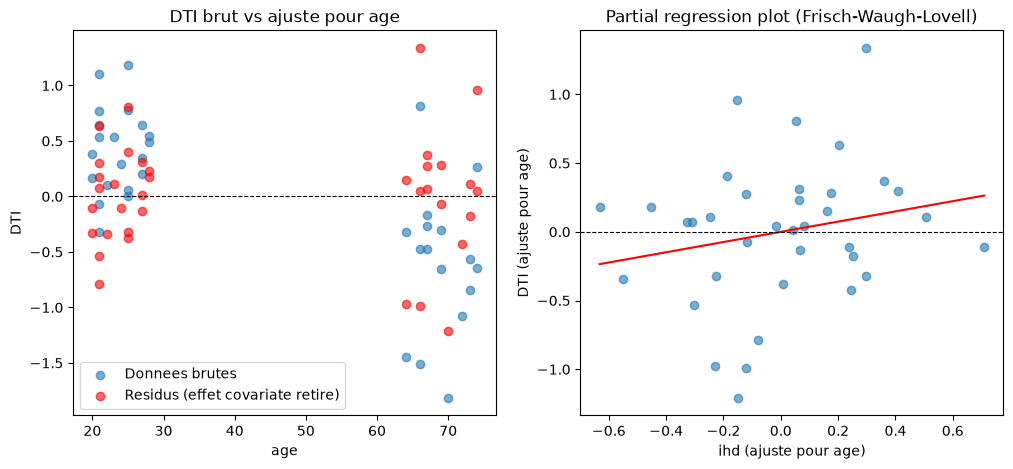

--- Regression jointe : DTI ~ ihd + age ---
Coefficient ihd (effet partiel ajuste pour age) : 0.3718
P-valeur ihd : 0.2284
Coefficient age : -0.0178
P-valeur age : 0.0015
R-carre : 0.503


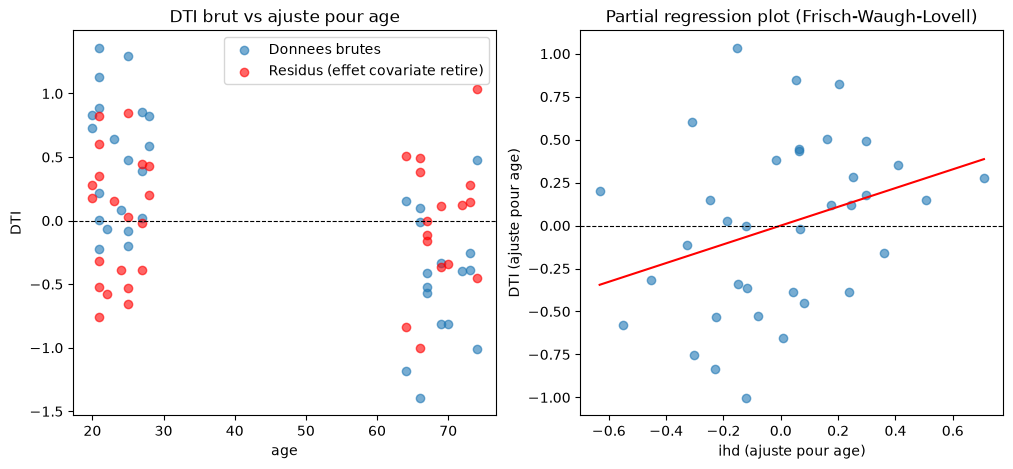

--- Regression jointe : DTI ~ ihd + age ---
Coefficient ihd (effet partiel ajuste pour age) : 0.5455
P-valeur ihd : 0.0603
Coefficient age : -0.0145
P-valeur age : 0.0045
R-carre : 0.525


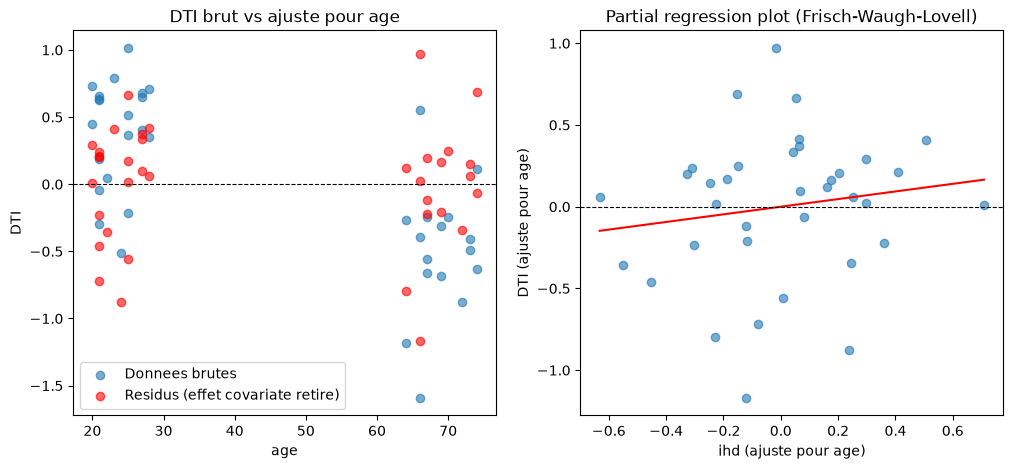

--- Regression jointe : DTI ~ ihd + age ---
Coefficient ihd (effet partiel ajuste pour age) : 0.2333
P-valeur ihd : 0.3824
Coefficient age : -0.0162
P-valeur age : 0.0010
R-carre : 0.489


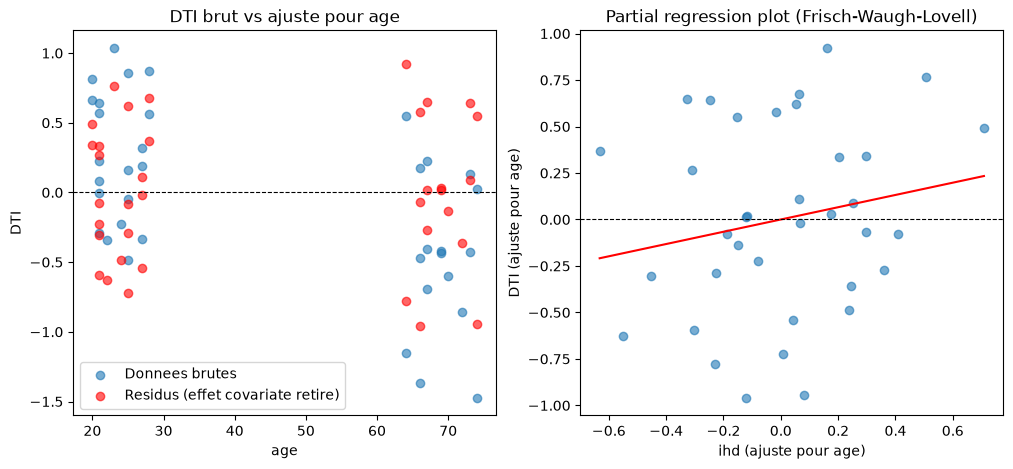

--- Regression jointe : DTI ~ ihd + age ---
Coefficient ihd (effet partiel ajuste pour age) : 0.3300
P-valeur ihd : 0.2741
Coefficient age : -0.0121
P-valeur age : 0.0220
R-carre : 0.358


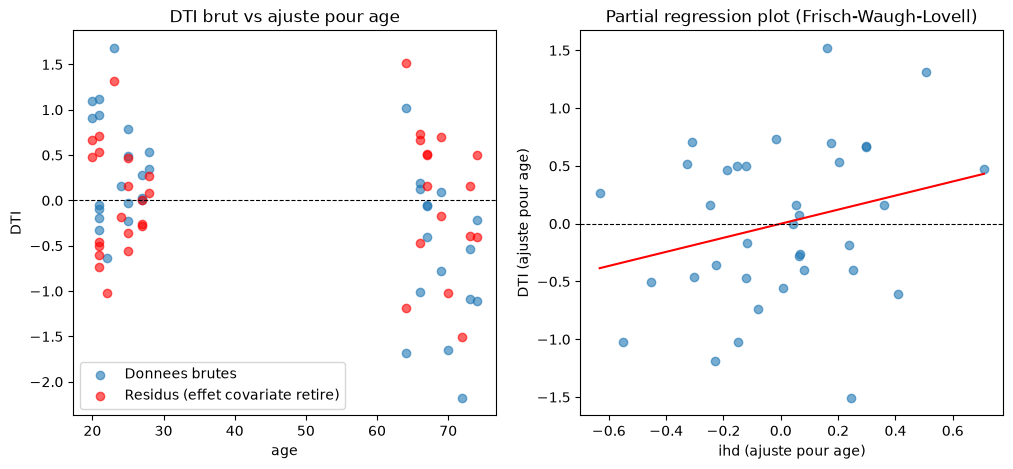

--- Regression jointe : DTI ~ ihd + age ---
Coefficient ihd (effet partiel ajuste pour age) : 0.6090
P-valeur ihd : 0.1290
Coefficient age : -0.0145
P-valeur age : 0.0358
R-carre : 0.382


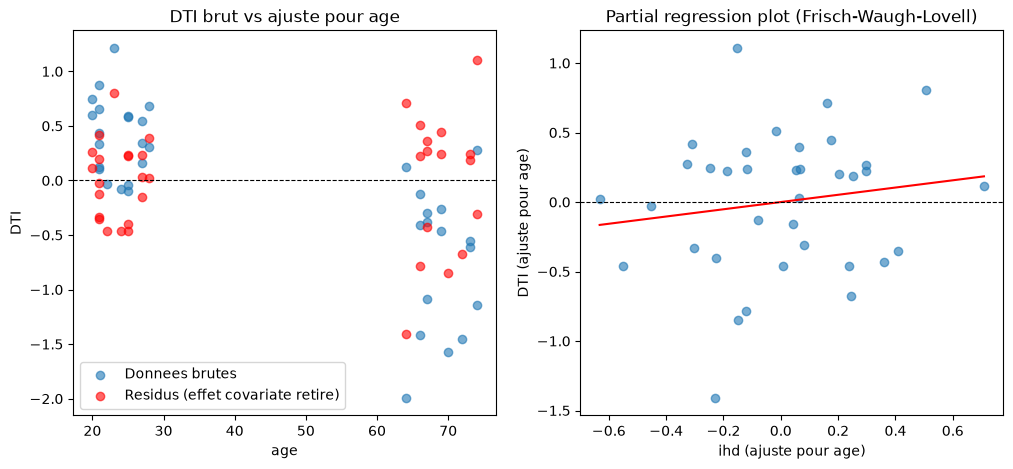

--- Regression jointe : DTI ~ ihd + age ---
Coefficient ihd (effet partiel ajuste pour age) : 0.2606
P-valeur ihd : 0.3856
Coefficient age : -0.0213
P-valeur age : 0.0002
R-carre : 0.557


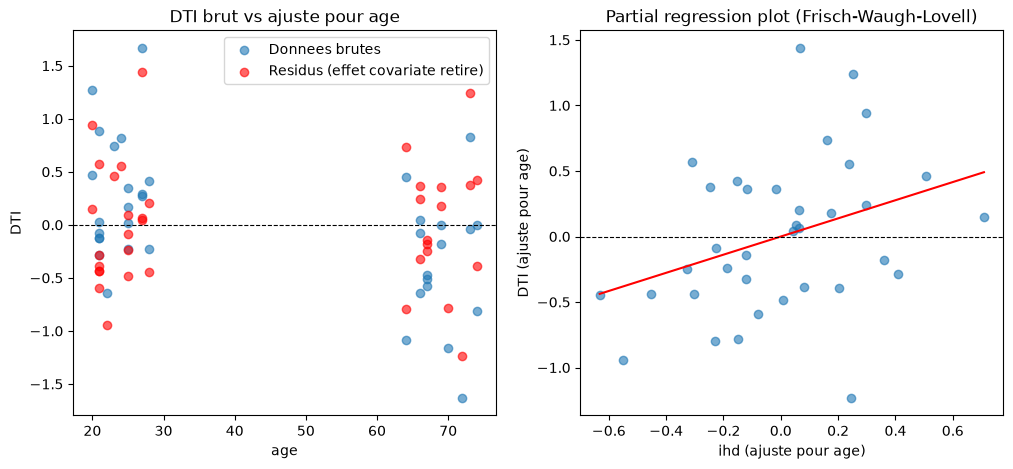

--- Regression jointe : DTI ~ ihd + age ---
Coefficient ihd (effet partiel ajuste pour age) : 0.6923
P-valeur ihd : 0.0416
Coefficient age : -0.0063
P-valeur age : 0.2617
R-carre : 0.322


In [ ]:
fig,axs=plt.subplots(8,2,figsize=(10,8*3))

for cc in range(1,8):
            
    data = DTI_IHD[DTI_IHD.columns[10*(cc-1):10*(cc-1)+nseg].tolist()].mean(axis=1)

    np.random.seed(42)
    n = 100
    df = pd.DataFrame({
        'DTI': data,  # Variable indépendante
        'age': age,  # Variable de contrôle
        'ihd': ihd   # Variable dépendante
    })
    
    joint_model = test_covariate_adjusted_association(
    df,
    outcome_col='DTI',
    covariate_col='age',
    predictor_col='ihd',
    plot=True,
   cc-1
    )